Week 3 Assignment

Name: Harshika Mittal
College: IGDTUW
Enrollment number: 07301172025

## Exploratory Data Analysis (EDA) and
## Machine Learning on Agricultural Yield Dataset


##Part A: Understanding the Dataset


Q1. Dataset Overview: LOAD DATASET


In [1]:
from google.colab import files
uploaded = files.upload()



Saving agriculture_ml_dataset_cw.csv to agriculture_ml_dataset_cw.csv


In [2]:
import pandas as pd
df = pd.read_csv(next(iter(uploaded)))
df.head()

,Crop_Type,Soil_Type,Region,Season,Irrigation,Fertilizer,Rainfall,Temperature,Humidity,Nitrogen,Yield
0,Wheat,Silty,South,Kharif,Sprinkler,Chemical,93.7,22.9,69.0,115.0,5.13
1,Cotton,NaN,West,Zaid,Flood,Organic,146.9,25.6,NaN,71.0,5.40
2,Cotton,Clay,North,Kharif,Drip,Chemical,108.7,22.1,NaN,86.0,4.26
3,Maize,Clay,South,Kharif,Sprinkler,Chemical,72.3,26.8,69.4,44.0,4.35
4,Maize,Silty,West,Kharif,Flood,Organic,119.9,26.3,44.3,48.0,4.88


How many rows and columns are present?

In [3]:
print("Shape of Dataset:")
print(df.shape)


Shape of Dataset:
(2020, 11)


What are the names of all columns?


In [4]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Yield']


Display the first 10 records.

In [5]:
print("\nFirst 10 Records:")
print(df.head(10))


First 10 Records:
   Crop_Type Soil_Type Region  Season Irrigation Fertilizer  Rainfall  \
0      Wheat     Silty  South  Kharif  Sprinkler   Chemical      93.7   
1     Cotton       NaN   West    Zaid      Flood    Organic     146.9   
2     Cotton      Clay  North  Kharif       Drip   Chemical     108.7   
3      Maize      Clay  South  Kharif  Sprinkler   Chemical      72.3   
4      Maize     Silty   West  Kharif      Flood    Organic     119.9   
5  Sugarcane     Loamy   West    Rabi      Flood      Mixed     176.4   
6      Wheat      Clay  South    Rabi  Sprinkler   Chemical     146.1   
7     Cotton     Loamy   East    Zaid        NaN    Organic     200.6   
8       Rice     Silty  North    Rabi       Drip      Mixed     136.2   
9      Wheat     Sandy  North    Rabi  Sprinkler    Organic     215.7   

   Temperature  Humidity  Nitrogen  Yield  
0         22.9      69.0     115.0   5.13  
1         25.6       NaN      71.0   5.40  
2         22.1       NaN      86.0   4.26  
3

## Q2. Data Types and Missing Values


Check the data type of each column.

In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
Crop_Type       object
Soil_Type       object
Region          object
Season          object
Irrigation      object
Fertilizer      object
Rainfall       float64
Temperature    float64
Humidity       float64
Nitrogen       float64
Yield          float64
dtype: object


Identify whether any missing values are present.

In [7]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Crop_Type        0
Soil_Type      121
Region           0
Season           0
Irrigation     120
Fertilizer       0
Rainfall       121
Temperature    120
Humidity       122
Nitrogen       121
Yield            0
dtype: int64


If missing values exist, mention the affected columns.


In [8]:
missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with Missing Values:")
print(missing_cols.tolist())


Columns with Missing Values:
['Soil_Type', 'Irrigation', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen']


#Q3. Descriptive Statistics

summary statistics for all numerical features

In [9]:
summary = df.describe()

print(summary)

          Rainfall  Temperature     Humidity     Nitrogen        Yield
count  1899.000000  1900.000000  1898.000000  1899.000000  2020.000000
mean    129.723960    26.875421    67.740622    79.169036     5.442926
std      35.395931     4.104174    12.046501    22.876734     1.062772
min      22.800000    12.900000    30.600000    40.000000     1.740000
25%     107.100000    24.200000    59.500000    59.000000     4.700000
50%     128.100000    26.900000    67.650000    79.000000     5.430000
75%     153.500000    29.600000    75.800000    99.000000     6.172500
max     245.300000    43.100000   117.800000   119.000000     8.910000


Which feature has the highest mean value?


In [10]:
highest_mean = summary.loc['mean'].idxmax()
print("\nFeature with Highest Mean:")
print(highest_mean)


Feature with Highest Mean:
Rainfall


Which feature has the highest standard deviation?


In [11]:
highest_std = summary.loc['std'].idxmax()
print("\nFeature with Highest Standard Deviation:")
print(highest_std)


Feature with Highest Standard Deviation:
Rainfall


##Part B: Exploratory Data Analysis (EDA)


Q4. Distribution Analysis : create histograms for:

rainfall_mm


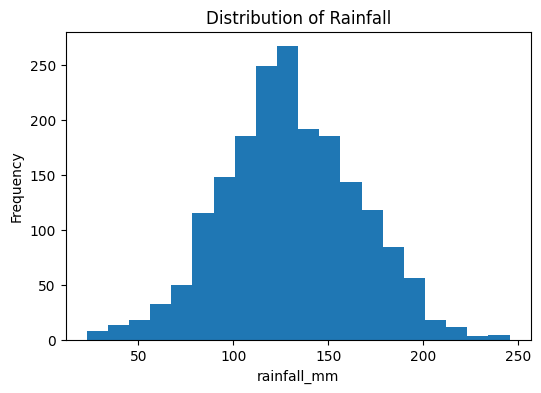

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Rainfall'], bins=20)
plt.title('Distribution of Rainfall')
plt.xlabel('rainfall_mm')
plt.ylabel('Frequency')
plt.show()

Observations:
The rainfall distribution is approximately bell-shaped and close to a normal distribution.
Most rainfall values are concentrated between 100 mm and 160 mm.
Very low (<50 mm) and very high (>220 mm) rainfall values are relatively rare.

temperature_c


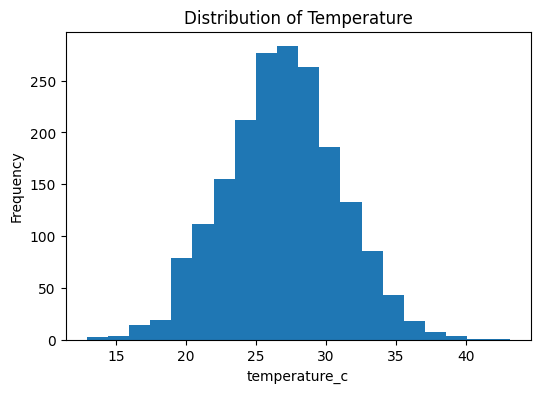

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['Temperature'], bins=20)
plt.title('Distribution of Temperature')
plt.xlabel('temperature_c')
plt.ylabel('Frequency')
plt.show()

observations: The temperature values show an approximately normal distribution centered around 28°C.
Most observations lie between 22°C and 34°C.
Extreme temperatures below 15°C and above 40°C occur infrequently.

fertilizer_kg

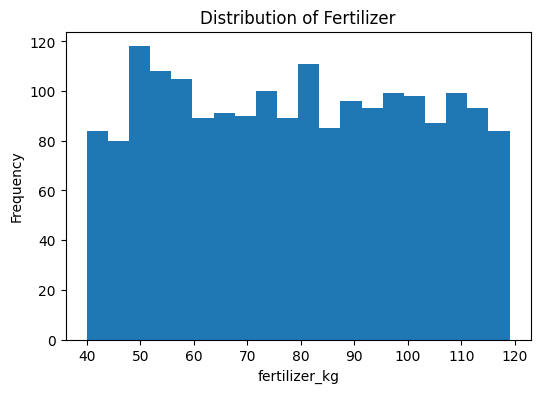

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['Nitrogen'], bins=20)
plt.title('Distribution of Fertilizer')
plt.xlabel('fertilizer_kg')
plt.ylabel('Frequency')
plt.show()

observations: The fertilizer distribution appears fairly uniform across the range of values.
Fertilizer usage is spread evenly between approximately 40 kg and 120 kg.
No significant peaks, skewness, or obvious outliers are visible in the distribution.

yield_ton_per_hectare

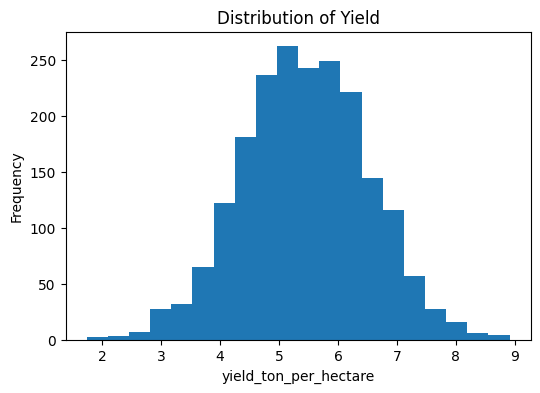

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df['Yield'], bins=20)
plt.title('Distribution of Yield')
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.show()

Observations: The crop yield distribution is approximately bell-shaped and resembles a normal distribution.
Most yield values are concentrated between 4 and 7 tons per hectare, with a peak around 5–6 tons per hectare.
Very low yields (<3 tons/hectare) and very high yields (>8 tons/hectare) are uncommon, indicating few extreme observations.

#Q5. Crop Type Analysis

Find the number of records for each crop type.

In [21]:

print(df['Crop_Type'].value_counts())

Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64


Create a count plot (bar chart) for crop_type.

Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64


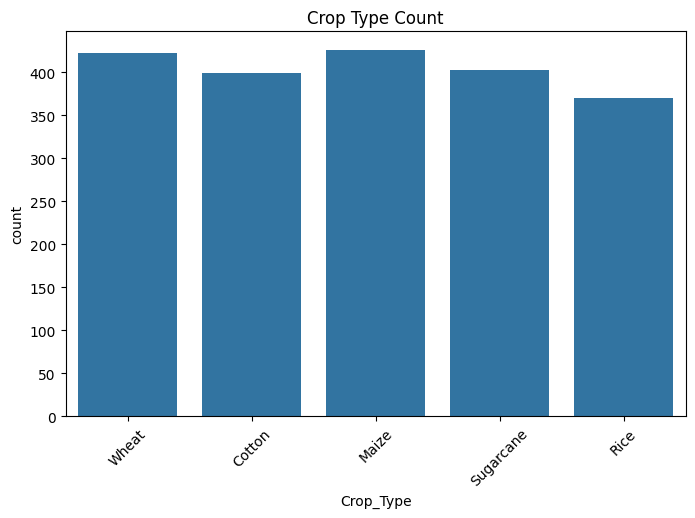

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df['Crop_Type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='Crop_Type', data=df)

plt.title('Crop Type Count')
plt.xticks(rotation=45)
plt.show()

Which crop appears most frequently?

In [23]:
print("\nMost Frequent Crop:")
print(df['Crop_Type'].value_counts().idxmax())


Most Frequent Crop:
Maize


#Q6. Soil Type Analysis

Find the frequency of each soil type.

In [24]:
print(df['Soil_Type'].value_counts())

Soil_Type
Silty    493
Loamy    482
Clay     463
Sandy    461
Name: count, dtype: int64


Create a count plot for soil_type.


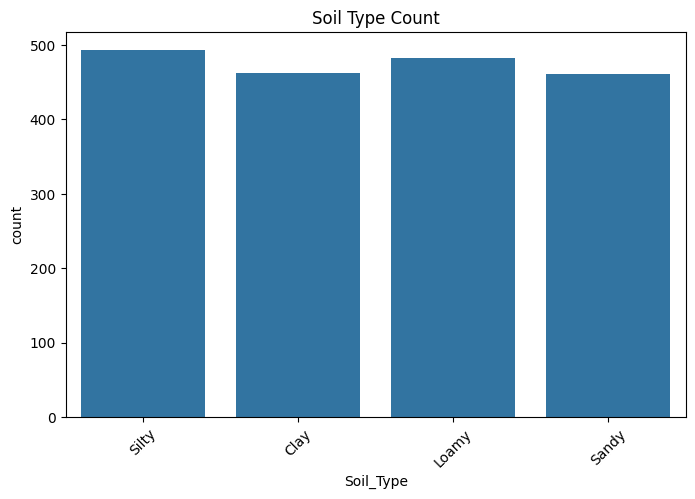

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='Soil_Type', data=df)

plt.title('Soil Type Count')
plt.xticks(rotation=45)
plt.show()

Which soil type is most common?

In [26]:
print("\nMost Common Soil Type:")
print(df['Soil_Type'].value_counts().idxmax())


Most Common Soil Type:
Silty


Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare

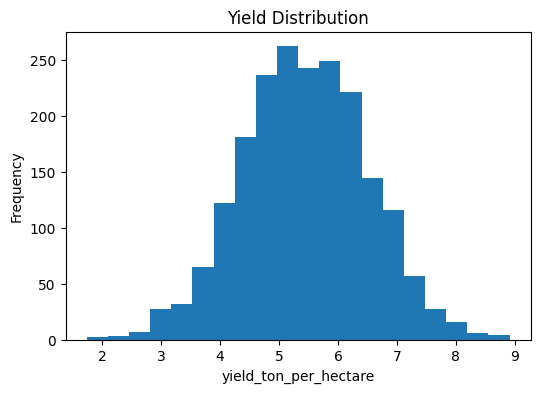

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df['Yield'], bins=20)
plt.title('Yield Distribution')
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.show()

Is the distribution approximately normal?

Yes, the distribution appears approximately normal. Most yield values are concentrated around 5-6 tons per hectare.

Are there any noticeable outliers?

A few observations at the lower and higher ends of the distribution may be considered outliers, but no major extreme outliers are visible.

#Q8. Scatter Plot Analysis

Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare

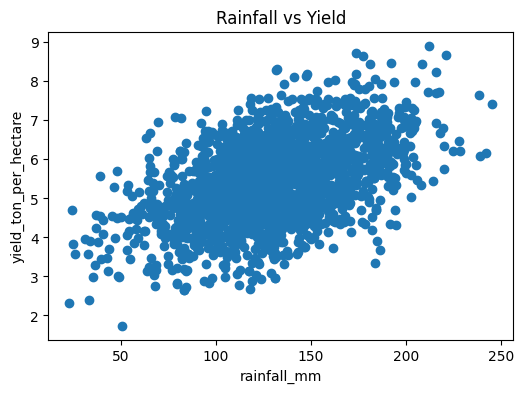

In [29]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rainfall'], df['Yield'])
plt.xlabel('rainfall_mm')
plt.ylabel('yield_ton_per_hectare')
plt.title('Rainfall vs Yield')
plt.show()

fertilizer_kg vs yield_ton_per_hectare


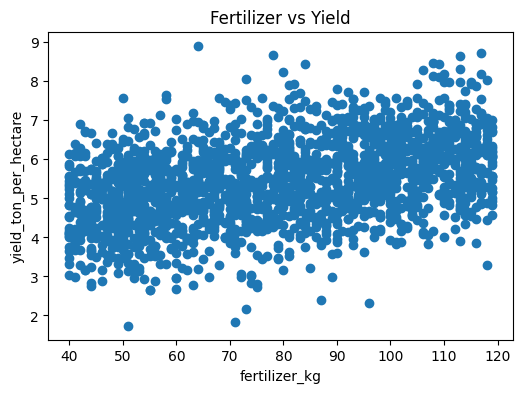

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(df['Nitrogen'], df['Yield'])
plt.xlabel('fertilizer_kg')
plt.ylabel('yield_ton_per_hectare')
plt.title('Fertilizer vs Yield')
plt.show()

Which feature appears to have a stronger relationship with yield?


Based on the scatter plots, rainfall appears to have a stronger relationship with crop yield than fertilizer. The Rainfall vs Yield plot shows a clearer positive trend, whereas the Fertilizer vs Yield plot exhibits greater dispersion of data points. This suggests that rainfall may have a greater influence on agricultural yield in this dataset.

#Q9. Correlation Analysis


Generate a correlation matrix for numerical features.


In [33]:

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
print(corr_matrix)

             Rainfall  Temperature  Humidity  Nitrogen     Yield
Rainfall     1.000000    -0.013519  0.002204 -0.031158  0.498788
Temperature -0.013519     1.000000  0.007016  0.029948  0.023503
Humidity     0.002204     0.007016  1.000000  0.017116  0.013557
Nitrogen    -0.031158     0.029948  0.017116  1.000000  0.395801
Yield        0.498788     0.023503  0.013557  0.395801  1.000000


Create a heatmap.

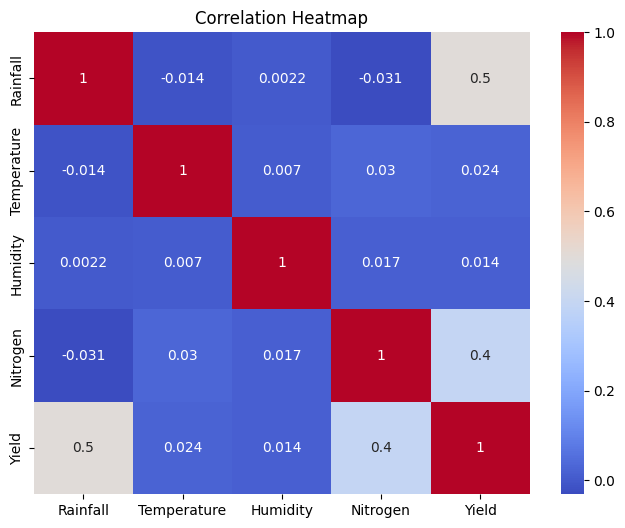

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Identify the top three features most correlated with crop yield.


In [37]:

top_3 = corr_matrix['Yield'].drop('Yield').sort_values(
    key=abs,
    ascending=False
).head(3)

print("Top 3 Features Most Correlated with Yield:")
print(top_3)

Top 3 Features Most Correlated with Yield:
Rainfall       0.498788
Nitrogen       0.395801
Temperature    0.023503
Name: Yield, dtype: float64


#Q10. Group-Based Analysis

Calculate the average yield for:
Each crop type


In [40]:
crop_yield = df.groupby('Crop_Type')['Yield'].mean()
print(crop_yield)

Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64


Each soil type

In [41]:
soil_yield = df.groupby('Soil_Type')['Yield'].mean()
print(soil_yield)

Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64


Which crop and soil type have the highest average yield?


Based on the group-wise analysis, Wheat is the crop type with the highest average yield, while Clay is the soil type associated with the highest average yield in the dataset. These results suggest that wheat cultivation and clay soil conditions may be more favorable for achieving higher agricultural productivity.

##Part C: Data Preparation


#Q11. Feature Encoding

Identify the categorical columns.


In [52]:


for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

Crop_Type      0
Soil_Type      0
Region         0
Season         0
Irrigation     0
Fertilizer     0
Rainfall       0
Temperature    0
Humidity       0
Nitrogen       0
Yield          0
dtype: int64


In [42]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer'],
      dtype='object')


Convert them into numerical form using One-Hot Encoding.

In [53]:
df_encoded = pd.get_dummies(df, drop_first=True)


Display the first five rows of the transformed dataset.

In [54]:
print("\nFirst 5 Rows of Encoded Dataset:")
print(df_encoded.head())


First 5 Rows of Encoded Dataset:
   Rainfall  Temperature   Humidity  Nitrogen  Yield  Crop_Type_Maize  \
0      93.7         22.9  69.000000     115.0   5.13            False   
1     146.9         25.6  67.740622      71.0   5.40            False   
2     108.7         22.1  67.740622      86.0   4.26            False   
3      72.3         26.8  69.400000      44.0   4.35             True   
4     119.9         26.3  44.300000      48.0   4.88             True   

   Crop_Type_Rice  Crop_Type_Sugarcane  Crop_Type_Wheat  Soil_Type_Loamy  ...  \
0           False                False             True            False  ...   
1           False                False            False            False  ...   
2           False                False            False            False  ...   
3           False                False            False            False  ...   
4           False                False            False            False  ...   

   Soil_Type_Silty  Region_North  Region

##Q12. Feature Selection

Separate:
Input features (X) and Target variable (y)


In [55]:
X = df_encoded.drop('Yield', axis=1)
y = df_encoded['Yield']

print("Target Variable:")
print(y.name)

print("\nShape of X:")
print(X.shape)

Target Variable:
Yield

Shape of X:
(2020, 20)


Target Variable (y): Yield
Input Features (X): All remaining columns after removing Yield.

##Part D: Machine Learning


Q13. Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Display the shape of: X_train, X_test, y_train, y_test

In [59]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1616, 20)
X_test shape: (404, 20)
y_train shape: (1616,)
y_test shape: (404,)


#Q14. Linear Regression Model

Train a Linear Regression model.


In [61]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Display the model coefficients and intercept.


In [62]:
print("Intercept:")
print(model.intercept_)

Intercept:
1.755899512491503


In [63]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
                 Feature  Coefficient
0               Rainfall     0.015030
1            Temperature     0.006897
2               Humidity     0.000433
3               Nitrogen     0.019346
4        Crop_Type_Maize     0.090065
5         Crop_Type_Rice    -0.010919
6    Crop_Type_Sugarcane     0.071520
7        Crop_Type_Wheat     0.115868
8        Soil_Type_Loamy    -0.115456
9        Soil_Type_Sandy    -0.069547
10       Soil_Type_Silty    -0.088306
11          Region_North     0.057605
12          Region_South     0.043416
13           Region_West     0.004842
14           Season_Rabi     0.022239
15           Season_Zaid    -0.028681
16      Irrigation_Flood    -0.053431
17  Irrigation_Sprinkler    -0.066225
18      Fertilizer_Mixed     0.058548
19    Fertilizer_Organic     0.004208


Which feature has the highest positive coefficient?

In [64]:
highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_feature)


Feature with Highest Positive Coefficient:
Feature        Crop_Type_Wheat
Coefficient           0.115868
Name: 7, dtype: object
